In [186]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [187]:
df = pd.read_csv("../data/raw/17th.csv", sep=";")

# 17th Lok Sabha Analysis — Exploratory Data Analysis

This notebook explores patterns and relationships within the 17th Lok Sabha
dataset.

The analysis is organized around specific research questions rather than
generating visualizations without a defined purpose.

For each question, the analysis follows:

**Research Question → Data Analysis → Visualization → Observation → Interpretation**

The objective is to identify meaningful patterns in parliamentary
participation, demographic characteristics, party representation, and
other available indicators.

### Research Question 1: What is the Age Distribution of Representatives?

### Purpose

To understand the overall age profile of representatives in the 17th Lok Sabha.

The analysis will examine the central tendency, spread, and range of ages
and identify any potential outliers.

In [188]:
df["Age"].describe()

count    554.000000
mean      59.167870
std       11.362782
min       30.000000
25%       51.000000
50%       60.000000
75%       68.000000
max       93.000000
Name: Age, dtype: float64

### Analysis

The `describe()` summary is used to examine:

- Number of available age observations
- Mean and median age
- Age range
- Interquartile range
- Standard deviation
- Potentially unusual minimum or maximum values

The five missing Age values are excluded from these calculations.

### Findings

The age data is available for 554 of the 559 representatives.

- The mean age is approximately **59.2 years**.
- The median age is **60 years**.
- The middle 50% of representatives are between **51 and 68 years** old.
- The youngest representative is **30 years** old.
- The oldest representative is **93 years** old.
- The standard deviation is approximately **11.4 years**.
- 5 representatives have missing Age values.

The mean and median are relatively close, suggesting that the overall age
distribution is not strongly shifted by extreme values.

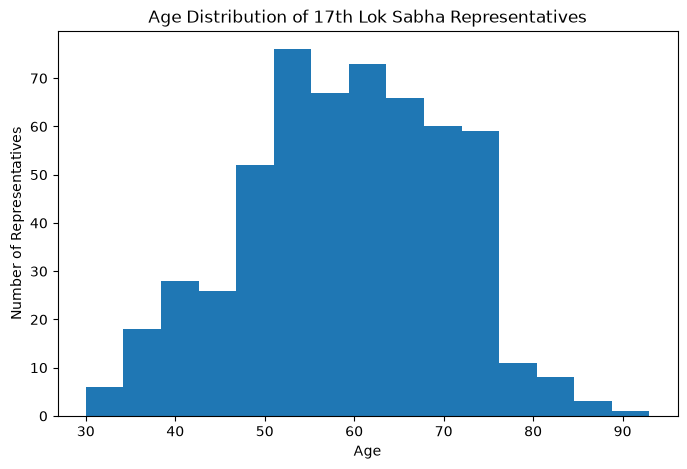

In [189]:
plt.figure(figsize=(8, 5))

plt.hist(df["Age"].dropna(), bins=15)

plt.title("Age Distribution of 17th Lok Sabha Representatives")
plt.xlabel("Age")
plt.ylabel("Number of Representatives")

plt.show()

### Visualization

A histogram was chosen to examine the overall distribution of representative
ages and identify the concentration, spread, and potential extreme values.

### Observation

The age distribution is concentrated primarily between approximately 50 and
75 years, with the highest concentration occurring in the early-to-mid 50s.

The number of representatives declines at older ages, particularly after
75 years. A small number of representatives are in the 80+ age range,
extending the distribution toward the upper end.

Overall, the distribution shows a broad concentration around middle and
older working ages, with a slight rightward tail.

### Research Question 2

**How is gender represented among representatives of the 17th Lok Sabha?**

### Purpose

To examine the overall gender composition of the representatives and identify the proportion of female and male representatives.

In [190]:
df["Gender"].value_counts()

Gender
Male      477
Female     82
Name: count, dtype: int64

In [191]:
df["Gender"].value_counts(normalize = True)*100

Gender
Male      85.330948
Female    14.669052
Name: proportion, dtype: float64

In [192]:
gender_distribution = pd.DataFrame({
    "Count": df["Gender"].value_counts(),
    "Percentage": df["Gender"].value_counts(normalize=True) * 100
})

gender_distribution

,Count,Percentage
Gender,,
Male,477,85.330948
Female,82,14.669052


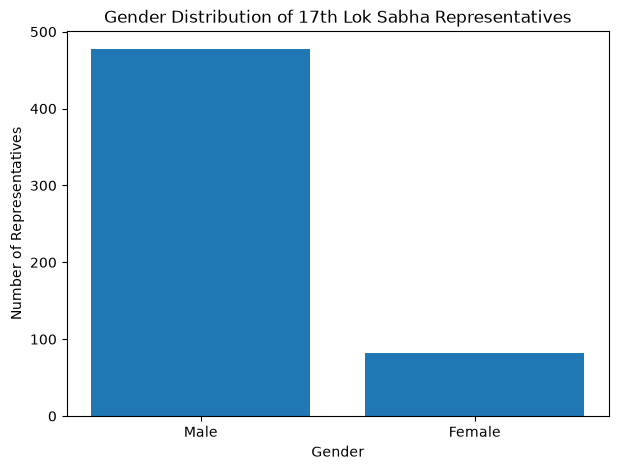

In [193]:
gender_counts = df["Gender"].value_counts()

plt.figure(figsize=(7,5))

plt.bar(gender_counts.index,gender_counts.values)

plt.title("Gender Distribution of 17th Lok Sabha Representatives")
plt.xlabel("Gender")
plt.ylabel("Number of Representatives")

plt.show()

### Observation

The gender distribution is strongly male-dominated.

- **477 representatives (85.3%)** are male.
- **82 representatives (14.7%)** are female.
- Male representatives therefore account for the large majority of the dataset.

This indicates substantial gender imbalance in the composition of the 17th Lok Sabha.

## Research Question 3: How Does Age Vary by Gender?

### Purpose

To compare the age distribution of male and female representatives and examine differences in their central tendency, spread, and range.

In [194]:
df.groupby("Gender")["Age"].describe()

,count,mean,std,min,25%,50%,75%,max
Gender,,,,,,,,
Female,82.0,53.878049,12.246834,30.0,45.0,54.0,61.0,79.0
Male,472.0,60.086864,10.958079,33.0,53.0,61.0,68.0,93.0


### Analysis

The age distribution was summarized separately by gender using descriptive statistics.

- Female representatives have a mean age of approximately **53.9 years** and a median age of **54 years**.
- Male representatives have a mean age of approximately **60.1 years** and a median age of **61 years**.
- The middle 50% of female representatives fall between **45 and 61 years**.
- The middle 50% of male representatives fall between **53 and 68 years**.
- Female representatives range from **30 to 79 years**, while male representatives range from **33 to 93 years**.

The descriptive statistics indicate a younger age distribution among female representatives in the dataset.

<Figure size 700x500 with 0 Axes>

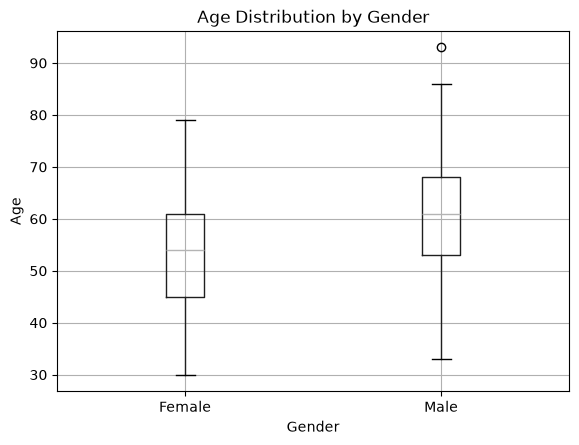

In [195]:
plt.figure(figsize=(7,5))

df.boxplot(column = "Age",by = "Gender" )

plt.title("Age Distribution by Gender")
plt.suptitle("")
plt.xlabel("Gender")
plt.ylabel("Age")

plt.show()

### Visualization

A box plot was chosen to compare the age distributions of male and female
representatives, allowing differences in central tendency, spread, range,
and potential outliers to be examined.

### Observation

The box plot shows that female representatives have a lower median age
than male representatives, at approximately 54 and 61 years respectively.

The middle 50% of female representatives is concentrated between 45 and
61 years, compared with 53 to 68 years for male representatives.

Male representatives also show a wider upper range, with a 93-year-old
representative appearing as a potential outlier.

Overall, the age distribution of female representatives is shifted toward
younger ages compared with male representatives in this dataset.

## Research Question 4: How Does Gender Representation Vary Across Parties and States?

### Purpose

To examine how female and male representation is distributed across political parties and states and identify notable differences in gender composition.

In [196]:
df.groupby("Party")["Gender"].value_counts()

Party                                     Gender
AJSU Party                                Male        1
Aam Aadmi Party                           Male        2
All India Anna Dravida Munnetra Kazhagam  Male        1
All India Majlis-E-Ittehadul Muslimeen    Male        2
All India Trinamool Congress              Male       14
                                          Female      9
All India United Democratic Front         Male        1
Apna Dal                                  Female      1
                                          Male        1
Bahujan Samaj Party                       Male        9
                                          Female      1
Bharat Rashtra Samithi                    Male        8
                                          Female      1
Bharatiya Janata Party                    Male      266
                                          Female     42
Biju Janata Dal                           Male        7
                                          Female      5

In [197]:
party_gender = pd.crosstab(df["Party"], df["Gender"])

party_gender

Gender,Female,Male
Party,,
AJSU Party,0,1
Aam Aadmi Party,0,2
All India Anna Dravida Munnetra Kazhagam,0,1
All India Majlis-E-Ittehadul Muslimeen,0,2
All India Trinamool Congress,9,14
All India United Democratic Front,0,1
Apna Dal,1,1
Bahujan Samaj Party,1,9
Bharat Rashtra Samithi,1,8


In [198]:
party_gender["Female %"] = (
    party_gender["Female"] /
    party_gender.sum(axis=1) * 100
)

party_gender.sort_values("Female %", ascending=False)

Gender,Female,Male,Female %
Party,,,
National Peoples Party,1,0,100.000000
Apna Dal,1,1,50.000000
Independent,2,2,50.000000
Biju Janata Dal,5,7,41.666667
All India Trinamool Congress,9,14,39.130435
Shiromani Akali Dal,1,2,33.333333
Nationalist Congress Party,1,4,20.000000
Yuvajana Sramika Rythu Congress Party,4,19,17.391304
Samajwadi Party,1,5,16.666667


In [199]:
party_gender["Total"] = party_gender["Female"] + party_gender["Male"]

major_parties = party_gender[party_gender["Total"] >= 5]

major_parties.sort_values("Female %", ascending=False)

Gender,Female,Male,Female %,Total
Party,,,,
Biju Janata Dal,5,7,41.666667,12
All India Trinamool Congress,9,14,39.130435,23
Nationalist Congress Party,1,4,20.000000,5
Yuvajana Sramika Rythu Congress Party,4,19,17.391304,23
Samajwadi Party,1,5,16.666667,6
Lok Jan Shakti Party,1,6,14.285714,7
Bharatiya Janata Party,42,266,13.636364,308
Indian National Congress,7,47,12.962963,54
Bharat Rashtra Samithi,1,8,11.111111,9


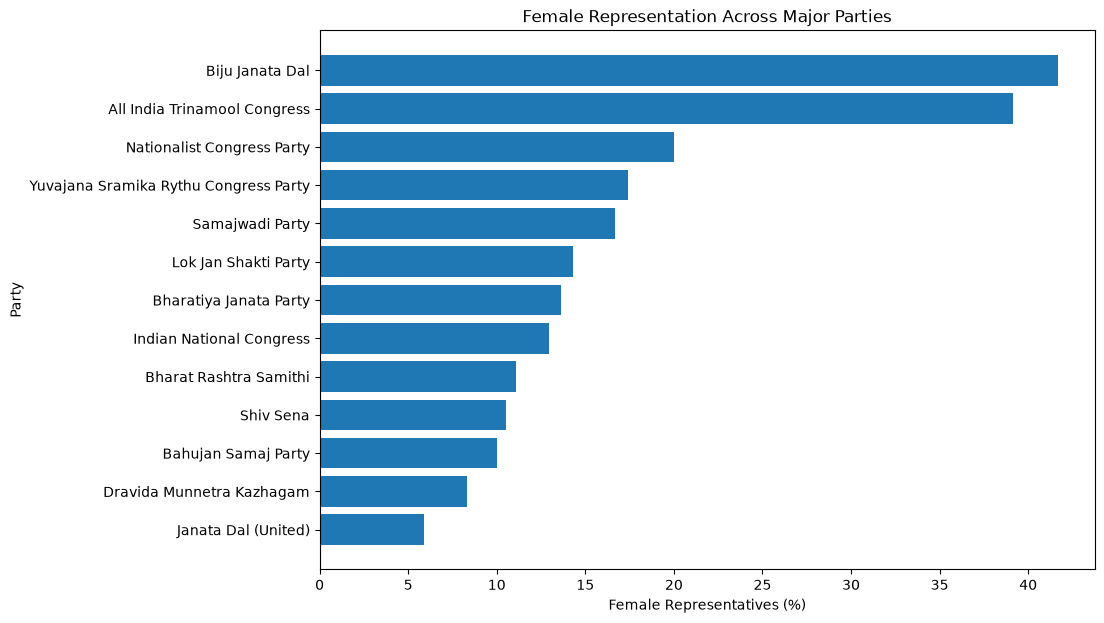

In [200]:
plt.figure(figsize=(10, 7))

major_parties_sorted = major_parties.sort_values("Female %")

plt.barh(
    major_parties_sorted.index,
    major_parties_sorted["Female %"]
)

plt.title("Female Representation Across Major Parties")
plt.xlabel("Female Representatives (%)")
plt.ylabel("Party")

plt.show()

### Observation

The proportion of female representatives varies considerably across the major parties.

Biju Janata Dal has the highest proportion of female representatives at approximately 41.7%, followed by All India Trinamool Congress at 39.1%. Nationalist Congress Party, Yuvajana Sramika Rythu Congress Party, and Samajwadi Party have female representation between approximately 16.7% and 20%.

Among the larger parties, Bharatiya Janata Party has 13.6% female representation, while Indian National Congress has 13.0%. Dravida Munnetra Kazhagam and Janata Dal (United) have lower proportions at 8.3% and 5.9% respectively.

The results show substantial variation in the proportion of female representatives across parties.

In [201]:
state_gender = pd.crosstab(df["State"],df["Gender"])

state_gender

Gender,Female,Male
State,,
Andaman and Nicobar Islands,0,1
Andhra Pradesh,4,22
Arunachal Pradesh,0,2
Assam,1,13
Bihar,3,39
Chandigarh,1,0
Chhattisgarh,3,8
Dadra and Nagar Haveli,1,1
Daman and Diu,0,1


In [202]:
state_gender["Female %"] = (
    state_gender["Female"] /
    state_gender.sum(axis=1) * 100
)

state_gender.sort_values("Female %", ascending=False)

Gender,Female,Male,Female %
State,,,
Chandigarh,1,0,100.000000
Meghalaya,1,1,50.000000
Dadra and Nagar Haveli,1,1,50.000000
Tripura,1,1,50.000000
Odisha,7,14,33.333333
Chhattisgarh,3,8,27.272727
West Bengal,11,32,25.581395
Gujarat,6,20,23.076923
Himachal Pradesh,1,4,20.000000


In [203]:
state_gender["Total"] = state_gender["Female"] + state_gender["Male"]

major_states = state_gender[state_gender["Total"] >= 5]

major_states.sort_values("Female %", ascending=False)

Gender,Female,Male,Female %,Total
State,,,,
Odisha,7,14,33.333333,21
Chhattisgarh,3,8,27.272727,11
West Bengal,11,32,25.581395,43
Gujarat,6,20,23.076923,26
Uttarakhand,1,4,20.000000,5
Himachal Pradesh,1,4,20.000000,5
Maharashtra,8,41,16.326531,49
Andhra Pradesh,4,22,15.384615,26
Uttar Pradesh,12,71,14.457831,83


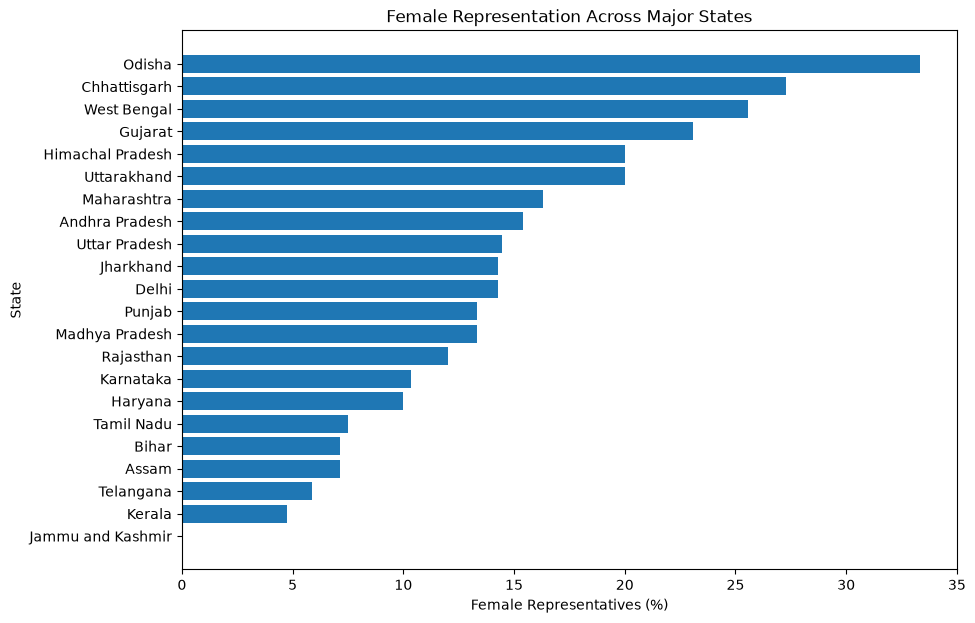

In [204]:
plt.figure(figsize=(10,7))

major_states_sorted = major_states.sort_values("Female %")

plt.barh(
    major_states_sorted.index,
    major_states_sorted["Female %"]
)

plt.title("Female Representation Across Major States")
plt.xlabel("Female Representatives (%)")
plt.ylabel("State")

plt.show()

### Observation

Female representation varies substantially across states and Union Territories.

Odisha has the highest proportion of female representatives at approximately 33.3%, followed by Chhattisgarh and West Bengal. Several states fall in the 10–25% range, while Tamil Nadu and Kerala have comparatively lower proportions in the dataset.

The variation is substantial across states, although percentages for states with relatively few representatives should be interpreted cautiously.

# Parliamentary Participation
### Question 5: How Is Attendance Distributed Among Representatives?

### Purpose

To examine the distribution of attendance among representatives and identify the overall attendance pattern, spread, and potential outliers.

In [205]:
df["Attendance"].head(20)

0     92.00%
1     19.80%
2     55.93%
3     63.07%
4     65.47%
5     55.73%
6     12.20%
7     89.33%
8     82.87%
9     69.82%
10    71.60%
11    98.60%
12    41.27%
13    94.40%
14    94.00%
15    14.27%
16    89.53%
17    30.87%
18    74.07%
19    82.13%
Name: Attendance, dtype: str

In [206]:
df["Attendance"].describe()

count        525
unique       387
top       91.20%
freq           5
Name: Attendance, dtype: object

In [207]:
df["Attendance"].value_counts().head(20)

Attendance
91.20%     5
83.27%     5
89.40%     5
94.00%     4
90.73%     4
98.80%     4
95.20%     4
86.33%     3
77.60%     3
74.73%     3
100.00%    3
76.33%     3
84.80%     3
94.47%     3
94.73%     3
91.40%     3
86.67%     3
90.93%     3
91.00%     3
78.20%     3
Name: count, dtype: int64

In [208]:
df["Attendance_numeric"] = (
    df["Attendance"]
    .str.replace("%", "", regex=False)
    .astype(float)
)

In [209]:
df["Attendance_numeric"].describe()

count    525.000000
mean      79.167010
std       17.264025
min        0.000000
25%       71.670000
50%       83.270000
75%       91.200000
max      100.000000
Name: Attendance_numeric, dtype: float64

In [210]:
df.loc[
    df["Attendance_numeric"].isin([0,100]),
    ["Name","Attendance","Minister","End of Term"]
    ]

,Name,Attendance,Minister,End of Term
64,Bhagirath Chaudhary,100.00%,No,In Office
281,Mohan Mandavi,100.00%,No,In Office
443,Sanjay Shamrao Dhotre,0.00%,Yes,In Office
507,Sunita Duggal,100.00%,No,In Office


### Visualization

A histogram was chosen to examine the distribution of attendance percentages, including the concentration of representatives across attendance ranges and the presence of unusually low or high values.

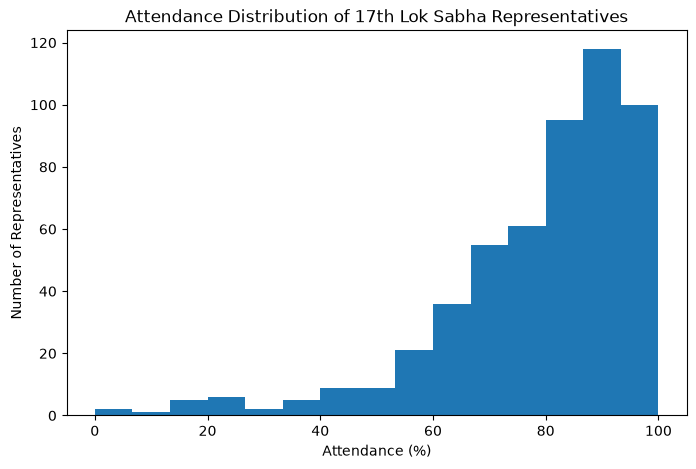

In [211]:
plt.figure(figsize = (8,5))

plt.hist(df["Attendance_numeric"].dropna(), bins = 15)

plt.title("Attendance Distribution of 17th Lok Sabha Representatives")
plt.xlabel("Attendance (%)")
plt.ylabel("Number of Representatives")

plt.show()

### Observation

The attendance distribution is concentrated heavily in the higher attendance range, with a large proportion of representatives having attendance between approximately 80% and 100%.

The distribution has a noticeable leftward tail, with relatively few representatives having attendance below 60%.

The median attendance is 83.27%, while the mean is lower at 79.17%, consistent with the influence of lower attendance values on the overall distribution.

The dataset also contains a 0% attendance value associated with a minister, which should be interpreted cautiously because ministerial attendance is not directly comparable to that of other representatives.

### Research Question 6: How Are Questions Distributed Among Representatives?

### Purpose

To examine the distribution of questions raised by representatives and identify the overall participation pattern, spread, and potential outliers.

In [212]:
df["Questions"].describe()

count    559.000000
mean     182.466905
std      150.450608
min        0.000000
25%       44.000000
50%      172.000000
75%      277.000000
max      654.000000
Name: Questions, dtype: float64

In [213]:
df.loc[
    df["Questions"].isin([0, df["Questions"].max()]),
    ["Name", "Questions", "Minister", "End of Term"]
]

,Name,Questions,Minister,End of Term
9,Afzal Ansari,0,No,In Office
17,Akhilesh Yadav,0,No,22-03-2022
22,Amit Anil Chandra Shah,0,Yes,In Office
34,Anurag Singh Thakur,0,Yes,In Office
37,Arjun Munda,0,Yes,In Office
...,...,...,...,...
494,Sukanta Majumdar,654,No,In Office
506,Sunil Soren,0,No,In Office
509,Suresh Channabasappa Angadi,0,Yes,23-09-2020
546,Vijay Kumar Singh,0,Yes,In Office


### Visualization

A histogram was chosen to examine the distribution of questions raised by representatives, including the concentration of participation and the presence of unusually high or low question counts.

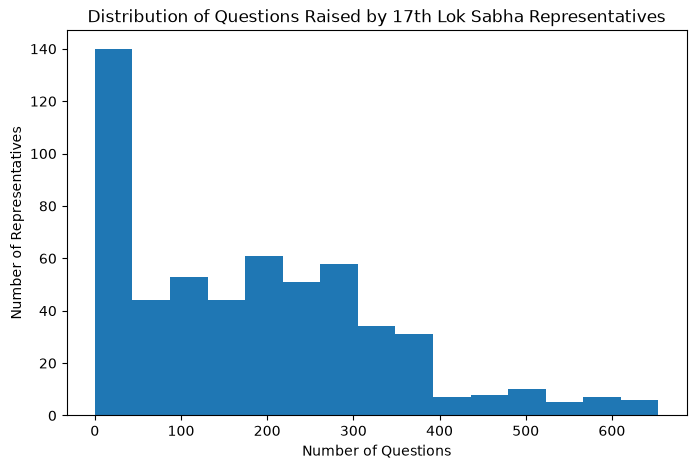

In [214]:
plt.figure(figsize=(8, 5))

plt.hist(
    df["Questions"],
    bins=15
)

plt.title("Distribution of Questions Raised by 17th Lok Sabha Representatives")
plt.xlabel("Number of Questions")
plt.ylabel("Number of Representatives")

plt.show()

### Observation

The distribution of questions is strongly right-skewed.

A large concentration of representatives recorded relatively low numbers of questions, particularly below 50 questions. The number of representatives generally declines as question counts increase, although there is substantial participation across the middle range.

A relatively small number of representatives recorded very high question counts, extending the distribution to a maximum of 654 questions.

The mean number of questions (182.47) is higher than the median (172), consistent with the right-skewed distribution.

### Research Question 7: How Is Debate Participation Distributed Among Representatives?

### Purpose

To examine the distribution of debate participation among representatives and identify the overall participation pattern, spread, and potential outliers.

In [215]:
df["Debates"].describe()

count     559.000000
mean       40.858676
std        77.796166
min         0.000000
25%         9.000000
50%        24.000000
75%        50.000000
max      1261.000000
Name: Debates, dtype: float64

In [216]:
df.loc[
    df["Debates"].isin([0,df["Debates"].max()]),
    ["Name","Debates","Minister","End of Term"]
    ]

,Name,Debates,Minister,End of Term
15,Ajay Singh Dharmendra Deol,0,No,In Office
22,Amit Anil Chandra Shah,0,Yes,In Office
24,Anant Kumar Hegde,0,No,In Office
34,Anurag Singh Thakur,0,Yes,In Office
37,Arjun Munda,0,Yes,In Office
38,Arjun Ram Meghwal,0,Yes,In Office
50,Ashwini Kumar Choubey,0,Yes,In Office
52,Atul Kumar Singh,0,No,In Office
53,Babul Supriya Baral (Babul Supriyo),0,Yes,22-10-2021
96,Choudhury Mohan Jatua,0,No,In Office


In [217]:
df.loc[
    df["Debates"].nlargest(10).index,
    ["Name","Debates","Minister","End of Term"]
    ]

,Name,Debates,Minister,End of Term
351,Pushpendra Singh Chandel,1261,No,In Office
235,Kuldeep Rai Sharma,834,No,In Office
261,Malook Nagar,606,No,In Office
124,DNV Senthilkumar S.,316,No,In Office
308,N.K.Premachandran,267,No,In Office
508,Supriya Sule,250,No,In Office
7,Adhir Ranjan Chowdhury,233,No,In Office
150,Girish Chandra,221,No,In Office
457,Saugata Roy,195,No,In Office
181,Jagdambika Pal,193,No,In Office


### Visualization

A histogram was chosen to examine the distribution of debate participation, particularly the concentration of representatives at lower participation levels and the extent of the high-participation tail.

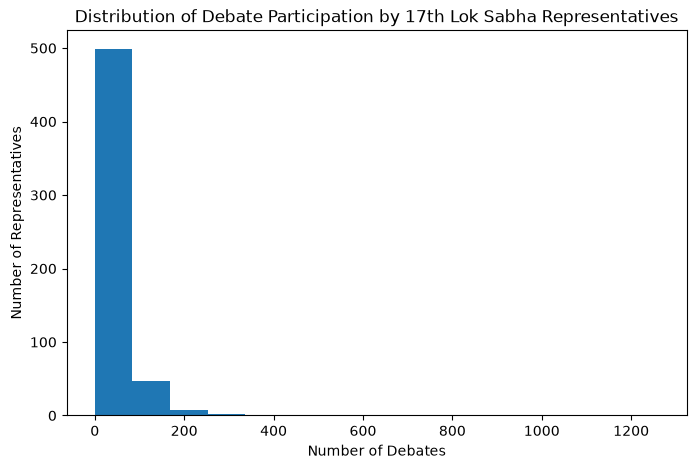

In [218]:
plt.figure(figsize = (8,5))

plt.hist(df["Debates"], bins = 15)

plt.title("Distribution of Debate Participation by 17th Lok Sabha Representatives")
plt.xlabel("Number of Debates")
plt.ylabel("Number of Representatives")

plt.show()

### Observation

The distribution of debate participation is strongly right-skewed.

Most representatives recorded relatively low numbers of debate participations, with the majority concentrated below approximately 100 debates. The number of representatives decreases substantially as debate participation increases.

A small group of representatives recorded substantially higher participation, extending the distribution to a maximum of 1,261 debates.

The mean of 40.86 debates is considerably higher than the median of 24, reflecting the influence of the high-participation tail.

### Question 8: How Are Private Member Bills Distributed Among Representatives?

### Purpose

To examine the distribution of Private Member Bills (PMBs) introduced by representatives and identify the overall participation pattern, spread, and potential outliers.

In [219]:
df["Private Member Bills"].describe()

count    559.000000
mean       1.304114
std        3.108060
min        0.000000
25%        0.000000
50%        0.000000
75%        1.000000
max       19.000000
Name: Private Member Bills, dtype: float64

In [220]:
df.loc[
    df["Private Member Bills"].isin([0,max(df["Private Member Bills"])]),
    ["Name","Private Member Bills","Minister","End of Term"]
    ]

,Name,Private Member Bills,Minister,End of Term
1,Abhishek Banerjee,0,No,In Office
2,Abu Hasem Khan Choudhury,0,No,In Office
3,Abu Taher Khan,0,No,In Office
4,Achyutananda Samanta,0,No,In Office
5,Adala Prabhakara Reddy,0,No,In Office
...,...,...,...,...
552,Virendra Singh,0,No,In Office
554,Vishnu Dutt Sharma,0,No,In Office
555,Vivek Narayan Shejwalkar,0,No,In Office
557,Y. Devendrappa,0,No,In Office


In [221]:
df.loc[
    df["Private Member Bills"].nlargest(10).index,
    ["Name","Private Member Bills","Minister","End of Term"]
    ]

,Name,Private Member Bills,Minister,End of Term
154,Gopal Chinayya Shetty,19,No,In Office
303,Nishikant Dubey,19,No,In Office
308,N.K.Premachandran,18,No,In Office
186,Janardan Singh Sigriwal,16,No,In Office
329,P.P. Chaudhary,16,No,In Office
508,Supriya Sule,16,No,In Office
20,Alok Kumar Suman,15,No,In Office
351,Pushpendra Singh Chandel,15,No,In Office
358,Rahul Ramesh Shewale,13,No,In Office
463,Shashi Tharoor,13,No,In Office


### Visualization

A histogram was chosen to examine the distribution of PMB participation and
identify the concentration of representatives at different levels of participation.

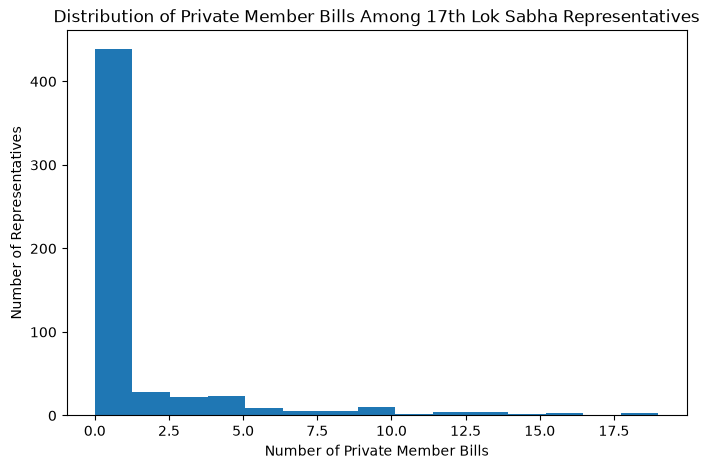

In [222]:
plt.figure(figsize = (8,5))

plt.hist(df["Private Member Bills"],bins = 15)

plt.title("Distribution of Private Member Bills Among 17th Lok Sabha Representatives")
plt.xlabel("Number of Private Member Bills")
plt.ylabel("Number of Representatives")

plt.show()

### Observation

The distribution of Private Member Bills is extremely right-skewed.

The overwhelming majority of representatives recorded very few Private Member Bills,
with most concentrated around 0–1 bills. The number of representatives decreases
sharply as PMB participation increases.

Only a small number of representatives recorded 10 or more Private Member Bills,
with the distribution extending to a maximum of 19.

This indicates substantial variation in PMB participation, with participation
concentrated among a relatively small group of representatives.

### Research Question 9: Is Attendance Associated with Questions, Debates, or Private Member Bills?

### Purpose

To examine whether attendance is associated with different forms of parliamentary participation, including Questions, Debates, and Private Member Bills.

In [223]:
participation_corr = df[
    ["Attendance_numeric","Questions","Debates","Private Member Bills"]].corr()

participation_corr

,Attendance_numeric,Questions,Debates,Private Member Bills
Attendance_numeric,1.000000,0.150345,0.214696,0.230092
Questions,0.150345,1.000000,0.350269,0.431243
Debates,0.214696,0.350269,1.000000,0.504426
Private Member Bills,0.230092,0.431243,0.504426,1.000000


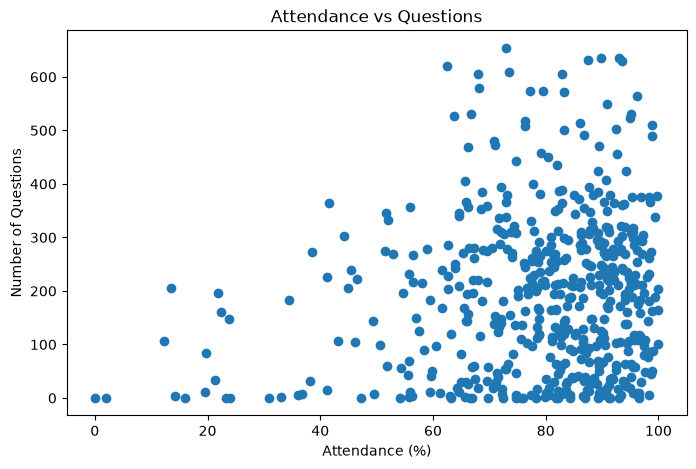

In [224]:
plt.figure(figsize=(8, 5))

plt.scatter(
    df["Attendance_numeric"],
    df["Questions"]
)

plt.title("Attendance vs Questions")
plt.xlabel("Attendance (%)")
plt.ylabel("Number of Questions")
plt.show()

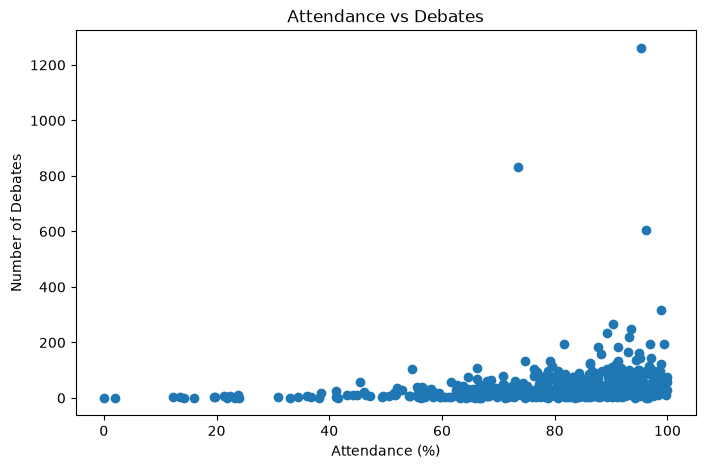

In [225]:
plt.figure(figsize=(8, 5))

plt.scatter(
    df["Attendance_numeric"],
    df["Debates"]
)

plt.title("Attendance vs Debates")
plt.xlabel("Attendance (%)")
plt.ylabel("Number of Debates")
plt.show()

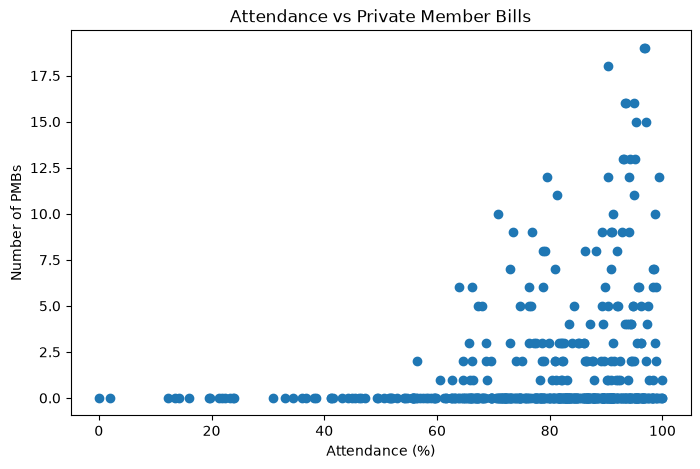

In [226]:
plt.figure(figsize=(8, 5))

plt.scatter(
    df["Attendance_numeric"],
    df["Private Member Bills"]
)

plt.title("Attendance vs Private Member Bills")
plt.xlabel("Attendance (%)")
plt.ylabel("Number of PMBs")
plt.show()

### Observation

The correlation analysis shows weak positive relationships between attendance
and all three participation indicators.

Attendance has the strongest association with Private Member Bills (r = 0.230),
followed by Debate participation (r = 0.215) and Questions (r = 0.150).

The scatter plots show substantial variation in participation levels at similar
attendance levels, particularly among representatives with high attendance.
This indicates that attendance alone does not strongly correspond to higher
participation across these indicators.

The participation indicators themselves show stronger relationships with one
another, particularly between Debates and Private Member Bills (r = 0.504).

These correlations describe associations within the dataset and do not establish
causal relationships.

### Research Question 10: Are There Unusual or Outlier Participation Patterns?

### Purpose

To identify representatives with unusually high or low values across the
participation indicators and examine unusual combinations of Questions,
Debates, and Private Member Bills.

In [227]:
participation_cols = ["Questions","Debates","Private Member Bills"]

for col in participation_cols:
    print(f"\n{col} - Top 10")
    print(df.nlargest(10, col)[["Name", col, "Party", "State", "Minister"]])

    print(f"\n{col} - Bottom 10")
    print(df.nsmallest(10, col)[["Name", col, "Party", "State", "Minister"]])


Questions - Top 10
                             Name  Questions                       Party  \
494              Sukanta Majumdar        654      Bharatiya Janata Party   
470           Shrirang Appa Barne        635                   Shiv Sena   
491                  Sudhir Gupta        635      Bharatiya Janata Party   
75            Bidyut Baran Mahato        632      Bharatiya Janata Party   
508                  Supriya Sule        629  Nationalist Congress Party   
23             Amol Ramsing Kolhe        621  Nationalist Congress Party   
235            Kuldeep Rai Sharma        610    Indian National Congress   
441    Sanjay Sadashivrao Mandlik        605                   Shiv Sena   
487         Subhash Ramrao Bhamre        605      Bharatiya Janata Party   
137  Gajanan Chandrakant Kirtikar        580                   Shiv Sena   

                           State Minister  
494                  West Bengal       No  
470                  Maharashtra       No  
491        

In [228]:
df[["Questions","Debates","Private Member Bills"]].corr()

,Questions,Debates,Private Member Bills
Questions,1.000000,0.350269,0.431243
Debates,0.350269,1.000000,0.504426
Private Member Bills,0.431243,0.504426,1.000000


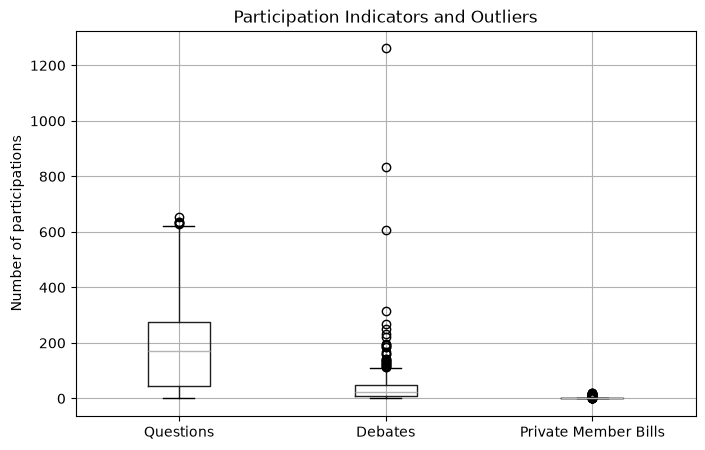

In [229]:
plt.figure(figsize = (8,5))

df[["Questions","Debates","Private Member Bills"]].boxplot()

plt.title("Participation Indicators and Outliers")
plt.ylabel("Number of participations")
plt.show()

In [230]:
participation_cols = ["Questions", "Debates", "Private Member Bills"]

outlier_flags = pd.DataFrame(index=df.index)

for col in participation_cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    
    outlier_flags[col] = (df[col] < lower) | (df[col] > upper)

df["Outlier_count"] = outlier_flags.sum(axis=1)

df[df["Outlier_count"] >= 2][
    ["Name", "Questions", "Debates", "Private Member Bills", "Outlier_count"]
].sort_values("Outlier_count", ascending=False)

,Name,Questions,Debates,Private Member Bills,Outlier_count
470,Shrirang Appa Barne,635,167,13,3
508,Supriya Sule,629,250,16,3
7,Adhir Ranjan Chowdhury,69,233,5,2
70,Bhartruhari Mahtab,311,185,10,2
124,DNV Senthilkumar S.,511,316,6,2
154,Gopal Chinayya Shetty,298,114,19,2
85,Chandra Prakash Joshi,328,159,8,2
109,Devji Patel,442,134,5,2
201,K. Navaskani,271,134,3,2
181,Jagdambika Pal,339,193,12,2


### Observation

The IQR-based analysis identified 24 representatives who were statistical
outliers in at least two of the three participation indicators.

Two representatives were identified as outliers across all three indicators:
Shrirang Appa Barne and Supriya Sule. The remaining representatives were
outliers across two indicators, with different combinations of Questions,
Debates, and Private Member Bills.

This indicates that unusually high participation is not limited to a single
indicator for some representatives, with a smaller group showing consistently
high values across multiple participation measures.

The correlation analysis also showed that Debates and Private Member Bills had
the strongest relationship among the three participation indicators
(r = 0.504).

These results identify unusual participation patterns but do not imply that
outlier representatives performed better overall.

### Question 11: How Does Participation Differ Between Ministers and Non-Ministers?

### Purpose

To compare participation across Questions, Debates, and Private Member Bills
between ministers and non-ministers and examine differences in their
distributions.

In [231]:
participation_cols = ["Questions", "Debates", "Private Member Bills"]

df.groupby("Minister")[participation_cols].describe()

Questions                                                            \
             count        mean         std  min    25%    50%     75%    max   
Minister                                                                       
No           488.0  203.229508  148.287419  0.0  76.75  202.5  289.75  654.0   
Yes           71.0   39.760563   61.589996  0.0   0.00    0.0   79.00  245.0   

         Debates             ...                Private Member Bills  \
           count       mean  ...    75%     max                count   
Minister                     ...                                       
No         488.0  45.147541  ...  54.25  1261.0                488.0   
Yes         71.0  11.380282  ...  18.50   109.0                 71.0   

                                                        
              mean       std  min  25%  50%  75%   max  
Minister                                                
No        1.475410  3.283868  0.0  0.0  0.0  1.0  19.0  
Yes       0.126761  0.607796  0.0  0.0  0.0  0.0   4.0  

[2 rows x 24 columns]

<Axes: title={'center': 'Questions'}, xlabel='Minister'>

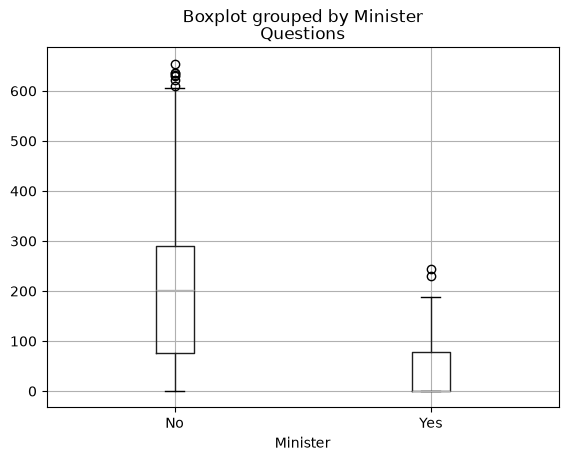

In [232]:
df.boxplot(column = "Questions",by = "Minister")

<Axes: title={'center': 'Debates'}, xlabel='Minister'>

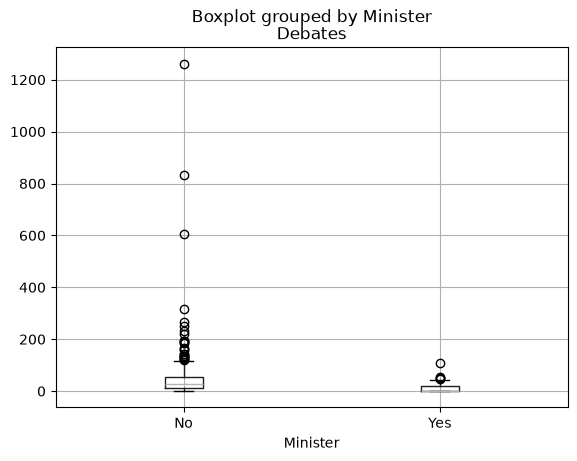

In [233]:
df.boxplot(column = "Debates",by = "Minister")

<Axes: title={'center': 'Private Member Bills'}, xlabel='Minister'>

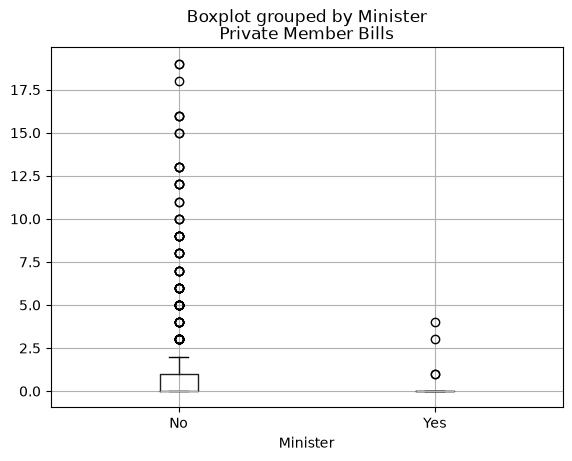

In [234]:
df.boxplot(column = "Private Member Bills",by = "Minister")

### Observation

The participation indicators show substantial differences between ministers
and non-ministers.

Non-ministers recorded higher participation across all three indicators. For
Questions, the mean was 203.23 for non-ministers compared with 39.76 for
ministers, while the median was 202.5 for non-ministers and 0 for ministers.

Debate participation was also higher among non-ministers, with a mean of 45.15
compared with 11.38 among ministers. Private Member Bills showed the largest
relative difference, with means of 1.48 for non-ministers and 0.13 for ministers.

The box plots show considerably wider distributions and more high-end outliers
among non-ministers.

These differences should be interpreted in the context of ministerial roles,
as ministers do not participate in parliamentary activities in exactly the same
way as non-minister representatives. Therefore, lower values in these
indicators should not be interpreted as lower overall parliamentary activity
or performance.

### Question 12: How Does Participation Vary Across Major Parties?

### Purpose

To compare the distribution of Questions, Debates, and Private Member Bills
across parties with at least five representatives and identify differences
in participation patterns.

In [235]:
party_counts = df["Party"].value_counts()
party_counts[party_counts >= 5]

Party
Bharatiya Janata Party                   308
Indian National Congress                  54
Dravida Munnetra Kazhagam                 24
All India Trinamool Congress              23
Yuvajana Sramika Rythu Congress Party     23
Shiv Sena                                 19
Janata Dal (United)                       17
Biju Janata Dal                           12
Bahujan Samaj Party                       10
Bharat Rashtra Samithi                     9
Lok Jan Shakti Party                       7
Samajwadi Party                            6
Nationalist Congress Party                 5
Name: count, dtype: int64

In [236]:
major_parties = party_counts[party_counts >= 5].index

party_participation = df[df["Party"].isin(major_parties)].groupby("Party")[participation_cols].describe()

party_participation

Questions                          \
                                          count        mean         std   
Party                                                                     
All India Trinamool Congress               23.0  106.608696   95.513321   
Bahujan Samaj Party                        10.0  129.700000   92.140050   
Bharat Rashtra Samithi                      9.0  234.111111  120.375916   
Bharatiya Janata Party                    308.0  163.756494  152.938117   
Biju Janata Dal                            12.0  201.166667  128.396285   
Dravida Munnetra Kazhagam                  24.0  271.833333  116.555143   
Indian National Congress                   54.0  217.648148  126.549738   
Janata Dal (United)                        17.0  167.588235   97.008414   
Lok Jan Shakti Party                        7.0   38.428571   42.480808   
Nationalist Congress Party                  5.0  450.400000  198.516498   
Samajwadi Party                             6.0    6.833333    7.305249   
Shiv Sena                                  19.0  388.052632  155.103361   
Yuvajana Sramika Rythu Congress Party      23.0  267.173913   94.223936   

                                                                            \
                                         min     25%    50%     75%    max   
Party                                                                        
All India Trinamool Congress             0.0    4.50  106.0  174.50  350.0   
Bahujan Samaj Party                      0.0   81.00  114.5  208.00  255.0   
Bharat Rashtra Samithi                   6.0  149.00  240.0  332.00  385.0   
Bharatiya Janata Party                   0.0   26.00  127.0  265.25  654.0   
Biju Janata Dal                         54.0  120.75  185.0  225.75  531.0   
Dravida Munnetra Kazhagam                0.0  214.75  265.5  292.75  511.0   
Indian National Congress                 0.0  105.50  237.5  299.25  610.0   
Janata Dal (United)                     10.0  128.00  175.0  239.00  304.0   
Lok Jan Shakti Party                     0.0    5.50   15.0   67.00  109.0   
Nationalist Congress Party             230.0  245.00  527.0  621.00  629.0   
Samajwadi Party                          0.0    0.25    6.0   12.50   16.0   
Shiv Sena                              141.0  276.00  362.0  524.00  635.0   
Yuvajana Sramika Rythu Congress Party    8.0  230.00  286.0  323.50  379.0   

                                      Debates              ...          \
                                        count        mean  ...     75%   
Party                                                      ...           
All India Trinamool Congress             23.0   29.782609  ...   30.50   
Bahujan Samaj Party                      10.0  135.400000  ...  141.50   
Bharat Rashtra Samithi                    9.0   26.444444  ...   37.00   
Bharatiya Janata Party                  308.0   33.496753  ...   41.25   
Biju Janata Dal                          12.0   45.750000  ...   46.50   
Dravida Munnetra Kazhagam                24.0   49.708333  ...   58.25   
Indian National Congress                 54.0   61.648148  ...   65.25   
Janata Dal (United)                      17.0   37.588235  ...   48.00   
Lok Jan Shakti Party                      7.0   12.285714  ...   19.50   
Nationalist Congress Party                5.0   78.600000  ...   42.00   
Samajwadi Party                           6.0   14.666667  ...   12.50   
Shiv Sena                                19.0   52.473684  ...   89.50   
Yuvajana Sramika Rythu Congress Party    23.0   32.304348  ...   40.00   

                                              Private Member Bills            \
                                          max                count      mean   
Party                                                                          
All India Trinamool Congress            195.0                 23.0  0.391304   
Bahujan Samaj Party                     606.0                 10.0  1.400000   
Bha

In [237]:
party_summary = (
    df[df["Party"].isin(major_parties)]
    .groupby("Party")[participation_cols]
    .agg(["mean", "median"])
)

party_summary

Questions            Debates         \
                                             mean median        mean median   
Party                                                                         
All India Trinamool Congress           106.608696  106.0   29.782609   16.0   
Bahujan Samaj Party                    129.700000  114.5  135.400000   81.0   
Bharat Rashtra Samithi                 234.111111  240.0   26.444444   22.0   
Bharatiya Janata Party                 163.756494  127.0   33.496753   20.0   
Biju Janata Dal                        201.166667  185.0   45.750000   32.5   
Dravida Munnetra Kazhagam              271.833333  265.5   49.708333   36.0   
Indian National Congress               217.648148  237.5   61.648148   38.5   
Janata Dal (United)                    167.588235  175.0   37.588235   35.0   
Lok Jan Shakti Party                    38.428571   15.0   12.285714   12.0   
Nationalist Congress Party             450.400000  527.0   78.600000   36.0   
Samajwadi Party                          6.833333    6.0   14.666667    6.5   
Shiv Sena                              388.052632  362.0   52.473684   31.0   
Yuvajana Sramika Rythu Congress Party  267.173913  286.0   32.304348   25.0   

                                      Private Member Bills         
                                                      mean median  
Party                                                              
All India Trinamool Congress                      0.391304    0.0  
Bahujan Samaj Party                               1.400000    0.0  
Bharat Rashtra Samithi                            0.333333    0.0  
Bharatiya Janata Party                            1.188312    0.0  
Biju Janata Dal                                   1.083333    0.0  
Dravida Munnetra Kazhagam                         1.666667    1.0  
Indian National Congress                          2.462963    0.0  
Janata Dal (United)                               1.117647    0.0  
Lok Jan Shakti Party                              0.000000    0.0  
Nationalist Congress Party                        3.200000    0.0  
Samajwadi Party                                   0.000000    0.0  
Shiv Sena                                         2.526316    0.0  
Yuvajana Sramika Rythu Congress Party             0.869565    0.0

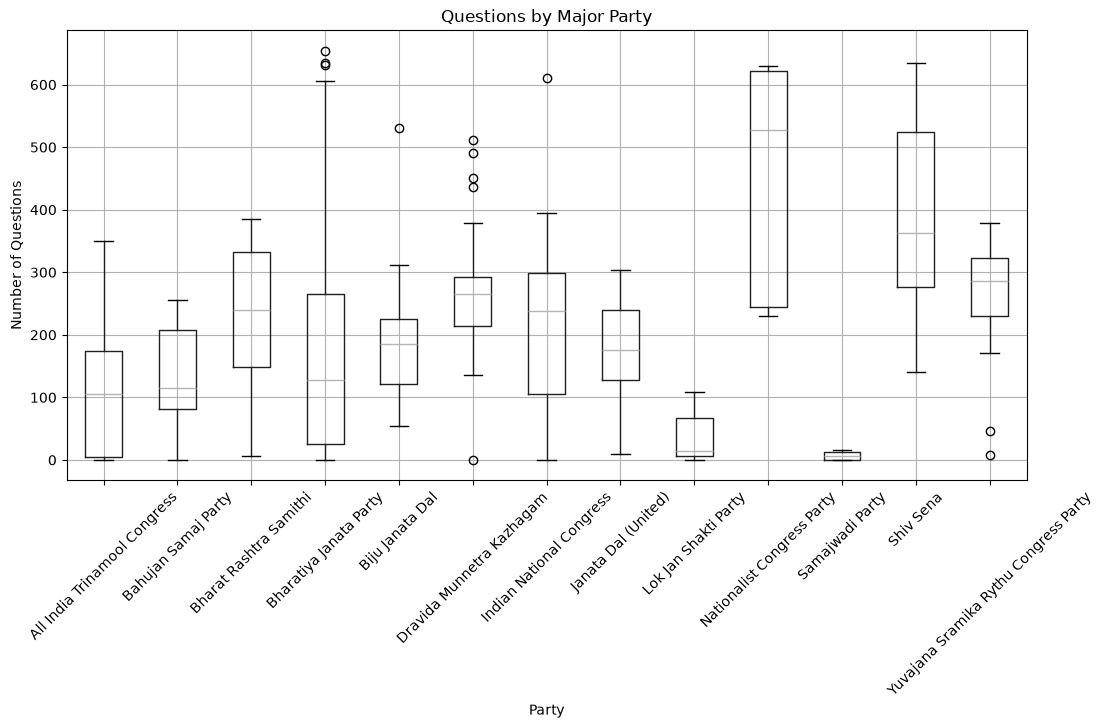

In [238]:
df_major = df[df["Party"].isin(major_parties)]

df_major.boxplot(
    column="Questions",
    by="Party",
    figsize=(12, 6)
)

plt.title("Questions by Major Party")
plt.suptitle("")
plt.xlabel("Party")
plt.ylabel("Number of Questions")
plt.xticks(rotation=45)
plt.show()

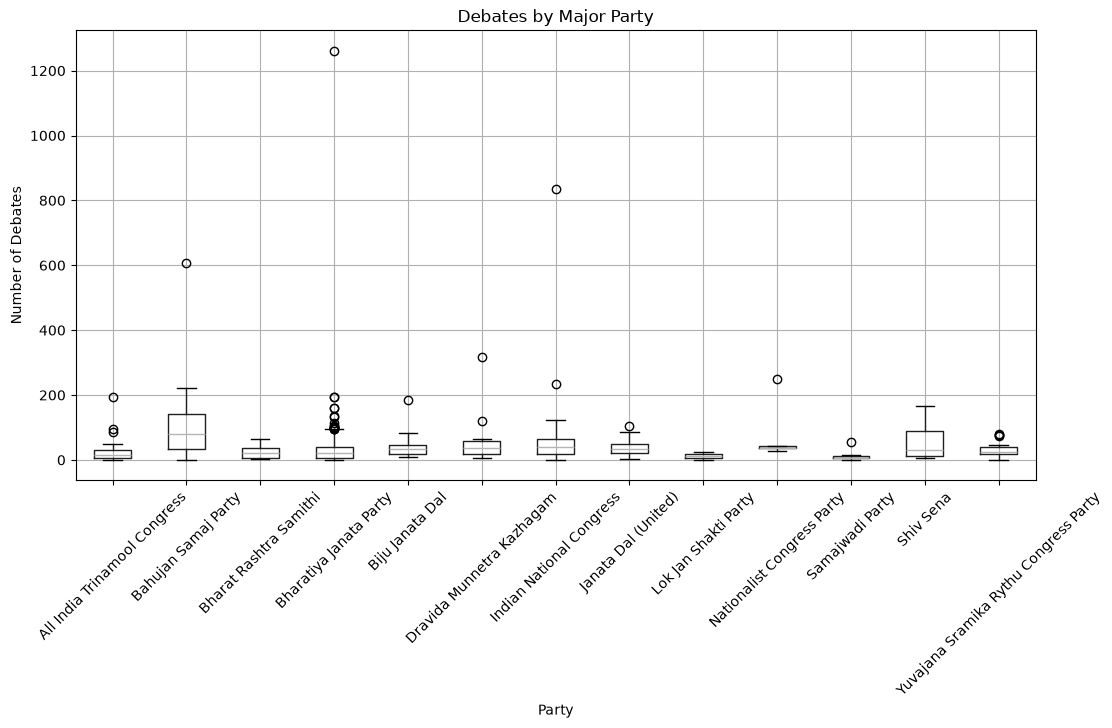

In [239]:
df_major.boxplot(
    column="Debates",
    by="Party",
    figsize=(12, 6)
)

plt.title("Debates by Major Party")
plt.suptitle("")
plt.xlabel("Party")
plt.ylabel("Number of Debates")
plt.xticks(rotation=45)
plt.show()

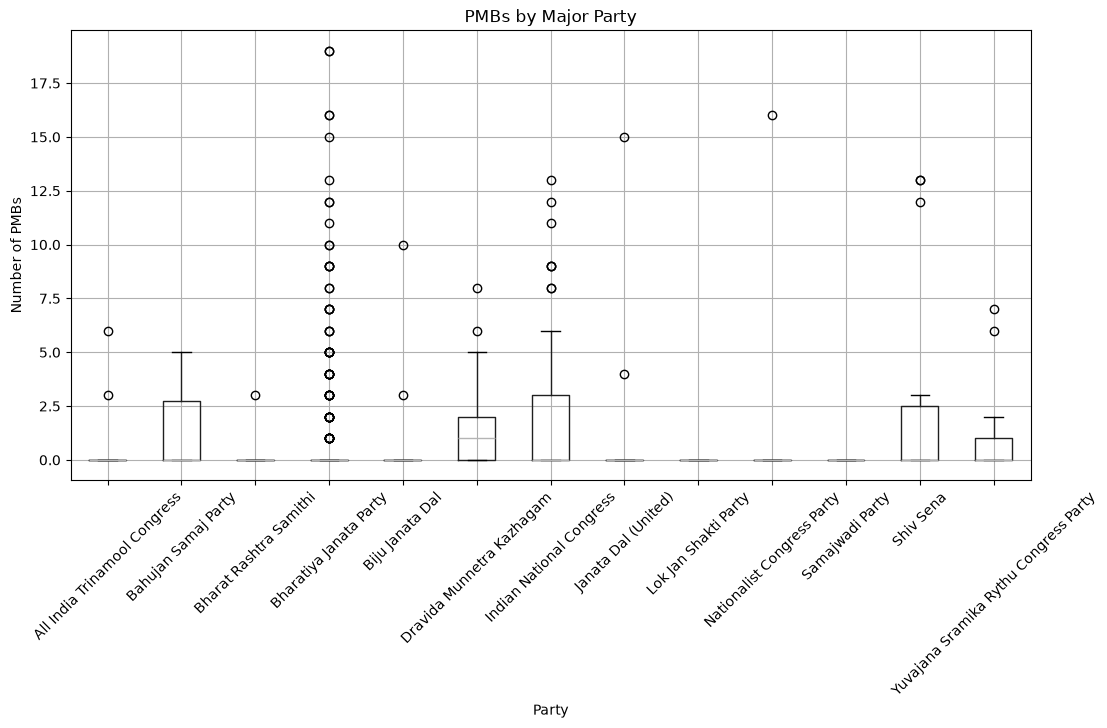

In [240]:
df_major = df[df["Party"].isin(major_parties)]

df_major.boxplot(
    column="Private Member Bills",
    by="Party",
    figsize=(12, 6)
)

plt.title("PMBs by Major Party")
plt.suptitle("")
plt.xlabel("Party")
plt.ylabel("Number of PMBs")
plt.xticks(rotation=45)
plt.show()

### Observation

Participation varies substantially across the parties included in the analysis.

Questions show considerable differences in both mean and median participation.
For example, the Nationalist Congress Party recorded a mean of 450.4 questions
and a median of 527, while the Samajwadi Party recorded a mean of 6.83 and a
median of 6.

Debate participation also varies considerably across parties, with differences
in both central tendency and spread. The box plots show substantial within-party
variation and several high-participation outliers.

Private Member Bills are much more concentrated around zero. Most parties have
a median of 0 PMBs, although some have higher means because participation is
concentrated among a smaller number of representatives.

The differences should be interpreted descriptively, since party sizes vary
substantially and these results do not establish that party affiliation causes
differences in parliamentary participation.

### Question 13: How Does Participation Vary Across States?

### Purpose

To compare the distribution of Questions, Debates, and Private Member Bills
across states and Union Territories with at least five representatives and
identify differences in participation patterns.

In [241]:
state_counts = df["State"].value_counts()
state_counts[state_counts>=5]

State
Uttar Pradesh        83
Maharashtra          49
West Bengal          43
Bihar                42
Tamil Nadu           40
Madhya Pradesh       30
Karnataka            29
Andhra Pradesh       26
Gujarat              26
Rajasthan            25
Odisha               21
Kerala               21
Telangana            17
Punjab               15
Assam                14
Jharkhand            14
Chhattisgarh         11
Haryana              10
Delhi                 7
Jammu and Kashmir     6
Uttarakhand           5
Himachal Pradesh      5
Name: count, dtype: int64

In [242]:
major_states = state_counts[state_counts>=5].index

state_participation = df[df["State"].isin(major_states)].groupby("State")[participation_cols].describe()

state_participation

Questions                                               \
                      count        mean         std   min     25%    50%   
State                                                                      
Andhra Pradesh         26.0  267.653846   89.564699   8.0  229.00  285.5   
Assam                  14.0  161.571429  126.350376   0.0   21.25  184.0   
Bihar                  42.0  129.285714  109.488007   0.0   11.25  128.0   
Chhattisgarh           11.0  151.909091  118.234897   0.0  103.50  116.0   
Delhi                   7.0  156.714286  140.912164   0.0   56.00  133.0   
Gujarat                26.0  183.846154  133.458516   0.0   90.75  168.5   
Haryana                10.0  161.300000  111.989136   0.0  105.75  179.0   
Himachal Pradesh        5.0   27.600000   26.015380   0.0    5.00   29.0   
Jammu and Kashmir       6.0   85.500000  118.919721   0.0    6.50   42.0   
Jharkhand              14.0  215.714286  180.924731   0.0   99.50  186.5   
Karnataka              29.0  176.413793  157.904021   0.0   32.00  131.0   
Kerala                 21.0  260.666667   85.855305  58.0  224.00  275.0   
Madhya Pradesh         30.0  139.600000  133.472611   0.0   36.50  119.5   
Maharashtra            49.0  346.510204  179.897554   0.0  245.00  346.0   
Odisha                 21.0  199.476190  133.432987   0.0  120.00  204.0   
Punjab                 15.0   84.333333  105.415279   0.0   11.50   43.0   
Rajasthan              25.0  229.600000  147.849022   0.0  167.00  258.0   
Tamil Nadu             40.0  247.275000  106.283363   0.0  191.25  252.0   
Telangana              17.0  199.529412  132.317855   0.0   92.00  197.0   
Uttar Pradesh          83.0  125.024096  137.588196   0.0   12.00   85.0   
Uttarakhand             5.0   56.400000   55.007272   9.0   18.00   45.0   
West Bengal            43.0  125.372093  137.438995   0.0   15.00   99.0   

                                 Debates             ...                 \
                      75%    max   count       mean  ...    75%     max   
State                                                ...                  
Andhra Pradesh     315.50  379.0    26.0  36.307692  ...  44.50    89.0   
Assam              266.50  354.0    14.0  27.571429  ...  38.25    78.0   
Bihar              226.00  322.0    42.0  35.142857  ...  49.75   104.0   
Chhattisgarh       217.50  372.0    11.0  24.454545  ...  37.50    41.0   
Delhi              228.50  395.0     7.0  30.857143  ...  49.00    74.0   
Gujarat            284.50  471.0    26.0  27.307692  ...  35.50   102.0   
Haryana            209.75  378.0    10.0  24.000000  ...  37.50    58.0   
Himachal Pradesh    41.00   63.0     5.0   6.800000  ...  11.00    16.0   
Jammu and Kashmir  103.75  310.0     6.0  41.166667  ...  57.50   126.0   
Jharkhand          307.50  632.0    14.0  48.357143  ...  74.50   193.0   
Karnataka          308.00  571.0    29.0  13.482759  ...  20.00    67.0   
Kerala             312.00  388.0    21.0  74.571429  ...  91.00   267.0   
Madhya Pradesh     188.25  635.0    30.0  28.966667  ...  41.00    96.0   
Maharashtra        508.00  635.0    49.0  51.979592  ...  71.00   250.0   
Odisha             231.00  531.0    21.0  42.142857  ...  46.00   185.0   
Punjab             106.00  367.0    15.0  30.066667  ...  50.50    79.0   
Rajasthan          318.00  523.0    25.0  64.960000  ...  87.00   185.0   
Tamil Nadu         278.50  511.0    40.0  51.300000  ...  58.25   316.0   
Telangana          332.00  385.0    17.0  22.117647  ...  36.00    66.0   
Uttar Pradesh      201.00  573.0    83.0  51.843373  ...  46.00  1261.0   
Uttarakhand         63.00  147.0     5.0  23.200000  ...  44.00    48.0   
West Bengal        186.50  654.0    43.0  31.069767  ...  32.00   233.0   

                  Private Member Bills                                     \
                                 count      mean       std  min  25%  50%   
State                                                                       
Andhra Pra

In [243]:
state_summary = (
    df[df["State"].isin(major_states)]
    .groupby("State")[participation_cols]
    .agg(["mean", "median"])
)

state_summary

Questions           Debates        Private Member Bills  \
                         mean median       mean median                 mean   
State                                                                         
Andhra Pradesh     267.653846  285.5  36.307692   29.0             1.000000   
Assam              161.571429  184.0  27.571429   27.0             1.357143   
Bihar              129.285714  128.0  35.142857   25.5             1.714286   
Chhattisgarh       151.909091  116.0  24.454545   29.0             0.000000   
Delhi              156.714286  133.0  30.857143   37.0             2.142857   
Gujarat            183.846154  168.5  27.307692   21.0             0.692308   
Haryana            161.300000  179.0  24.000000   21.5             0.400000   
Himachal Pradesh    27.600000   29.0   6.800000    5.0             0.000000   
Jammu and Kashmir   85.500000   42.0  41.166667   26.0             0.500000   
Jharkhand          215.714286  186.5  48.357143   31.0             3.285714   
Karnataka          176.413793  131.0  13.482759    9.0             0.000000   
Kerala             260.666667  275.0  74.571429   63.0             4.523810   
Madhya Pradesh     139.600000  119.5  28.966667   24.0             0.800000   
Maharashtra        346.510204  346.0  51.979592   31.0             2.571429   
Odisha             199.476190  204.0  42.142857   33.0             0.761905   
Punjab              84.333333   43.0  30.066667   19.0             1.000000   
Rajasthan          229.600000  258.0  64.960000   72.0             2.280000   
Tamil Nadu         247.275000  252.0  51.300000   40.0             1.475000   
Telangana          199.529412  197.0  22.117647   17.0             0.352941   
Uttar Pradesh      125.024096   85.0  51.843373   18.0             1.036145   
Uttarakhand         56.400000   45.0  23.200000   14.0             1.400000   
West Bengal        125.372093   99.0  31.069767   14.0             0.558140   

                          
                  median  
State                     
Andhra Pradesh       0.0  
Assam                0.0  
Bihar                0.0  
Chhattisgarh         0.0  
Delhi                0.0  
Gujarat              0.0  
Haryana              0.0  
Himachal Pradesh     0.0  
Jammu and Kashmir    0.0  
Jharkhand            0.0  
Karnataka            0.0  
Kerala               2.0  
Madhya Pradesh       0.0  
Maharashtra          0.0  
Odisha               0.0  
Punjab               0.0  
Rajasthan            0.0  
Tamil Nadu           0.5  
Telangana            0.0  
Uttar Pradesh        0.0  
Uttarakhand          0.0  
West Bengal          0.0

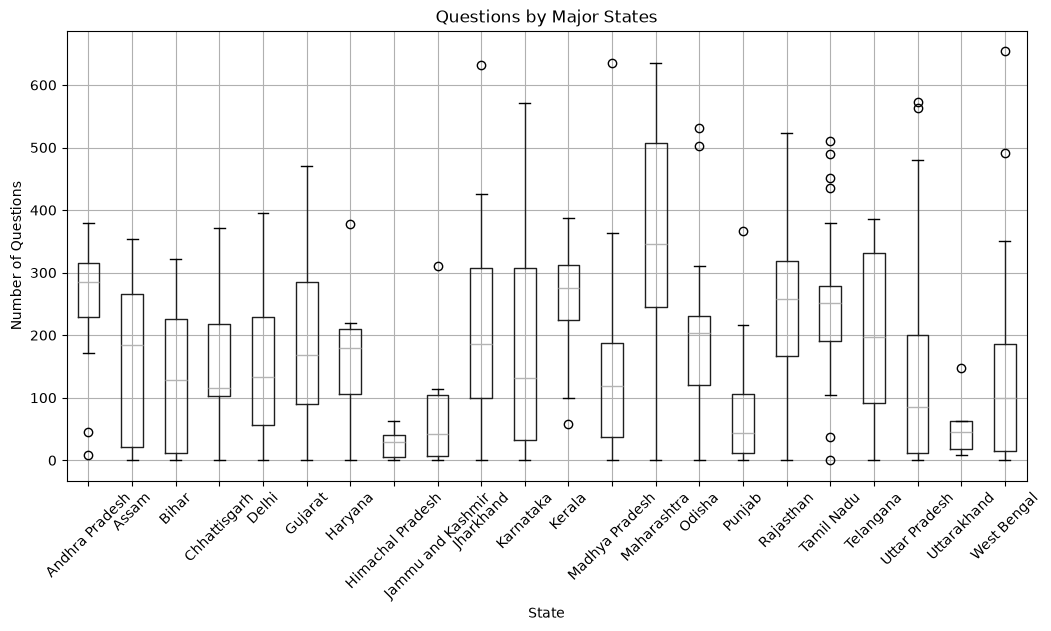

In [244]:
df_major1 = df[df["State"].isin(major_states)]

df_major1.boxplot(
    column="Questions",
    by="State",
    figsize=(12, 6)
)

plt.title("Questions by Major States")
plt.suptitle("")
plt.xlabel("State")
plt.ylabel("Number of Questions")
plt.xticks(rotation=45)
plt.show()

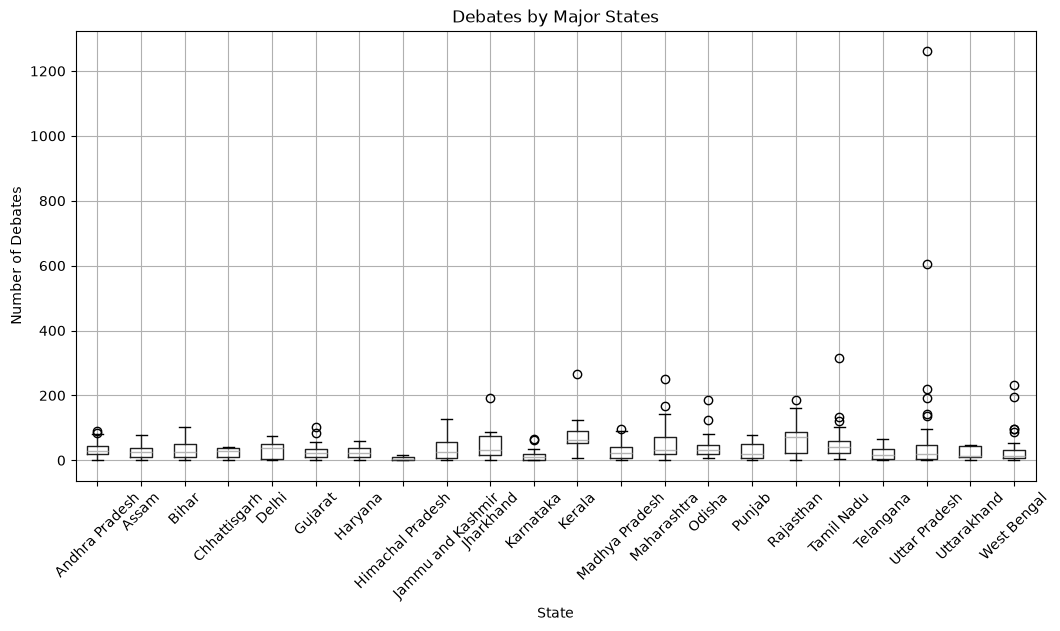

In [245]:
df_major1.boxplot(
    column="Debates",
    by="State",
    figsize=(12, 6)
)

plt.title("Debates by Major States")
plt.suptitle("")
plt.xlabel("State")
plt.ylabel("Number of Debates")
plt.xticks(rotation=45)
plt.show()

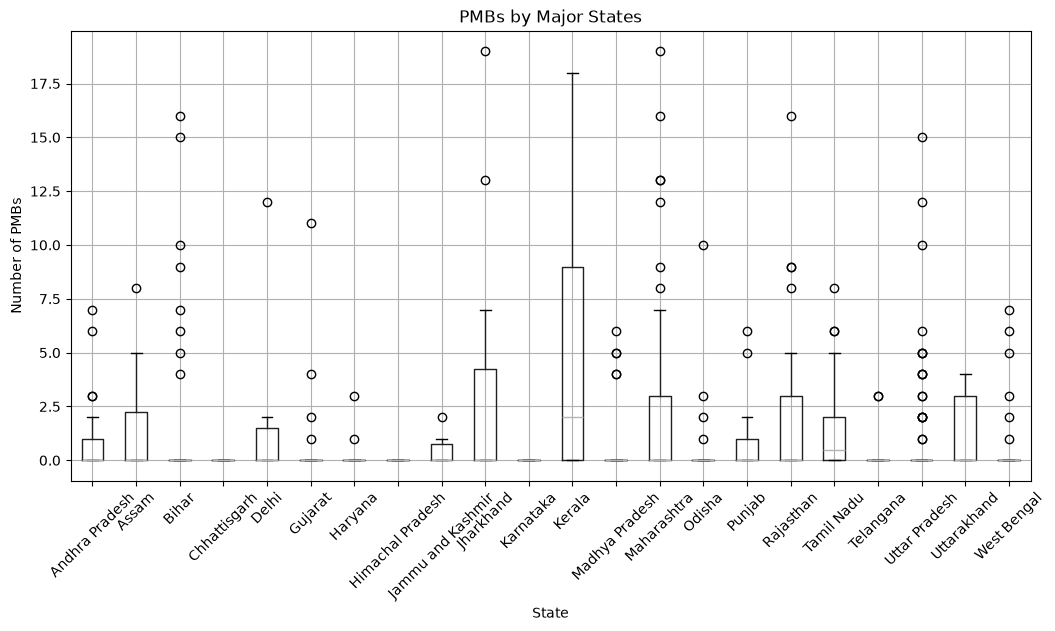

In [246]:
df_major1.boxplot(
    column="Private Member Bills",
    by="State",
    figsize=(12, 6)
)

plt.title("PMBs by Major States")
plt.suptitle("")
plt.xlabel("State")
plt.ylabel("Number of PMBs")
plt.xticks(rotation=45)
plt.show()

### Observation

Participation varies substantially across states and Union Territories.

Questions show considerable differences in both mean and median participation.
For example, Maharashtra recorded a mean of 346.51 questions and a median of
346, while Himachal Pradesh recorded a mean of 27.60 and a median of 29.

Debate participation also varies across states. Kerala recorded a mean of 74.57
debates and a median of 63, while Karnataka recorded a mean of 13.48 and a
median of 9. Several states also show substantial high-participation outliers.

Private Member Bill participation is concentrated around zero across most
states. Many states have a median of 0 PMBs, while Kerala has a median of 2.

The box plots also show substantial within-state variation, indicating that
state-level averages do not represent all representatives within a state.

These results are descriptive comparisons, and states with relatively few
representatives should be interpreted cautiously.

### Question 15: Which Participation Indicators Are Most Strongly Related?

### Purpose

To examine the strength and direction of the relationships between Questions,
Debate participation, and Private Member Bills.

In [247]:
df[["Questions", "Debates", "Private Member Bills"]].corr()

,Questions,Debates,Private Member Bills
Questions,1.000000,0.350269,0.431243
Debates,0.350269,1.000000,0.504426
Private Member Bills,0.431243,0.504426,1.000000


### Visualization

Correlation analysis was used to quantify the strength and direction of the
relationships between the three participation indicators.

Scatter plots were used to examine the relationships visually and identify
patterns or unusual observations.

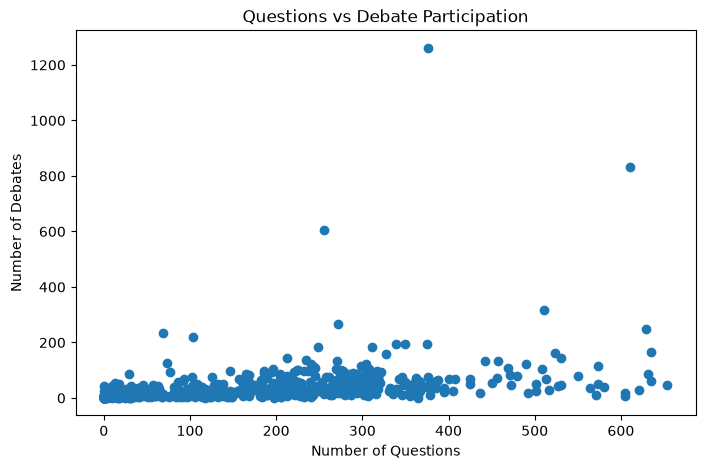

In [248]:
plt.figure(figsize=(8, 5))
plt.scatter(df["Questions"], df["Debates"])

plt.title("Questions vs Debate Participation")
plt.xlabel("Number of Questions")
plt.ylabel("Number of Debates")

plt.show()

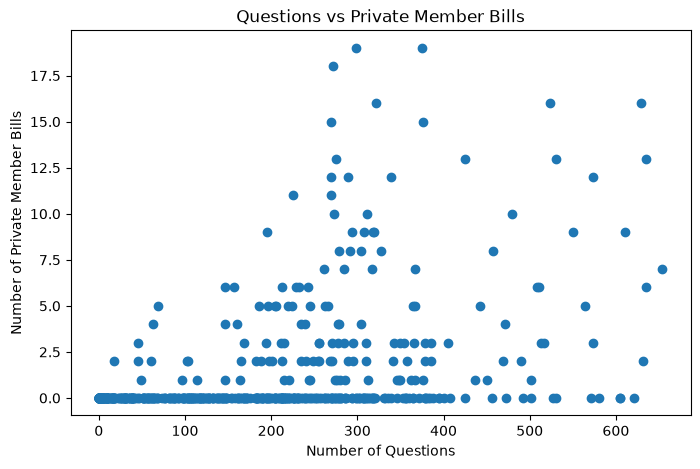

In [249]:
plt.figure(figsize=(8, 5))
plt.scatter(df["Questions"], df["Private Member Bills"])

plt.title("Questions vs Private Member Bills")
plt.xlabel("Number of Questions")
plt.ylabel("Number of Private Member Bills")

plt.show()

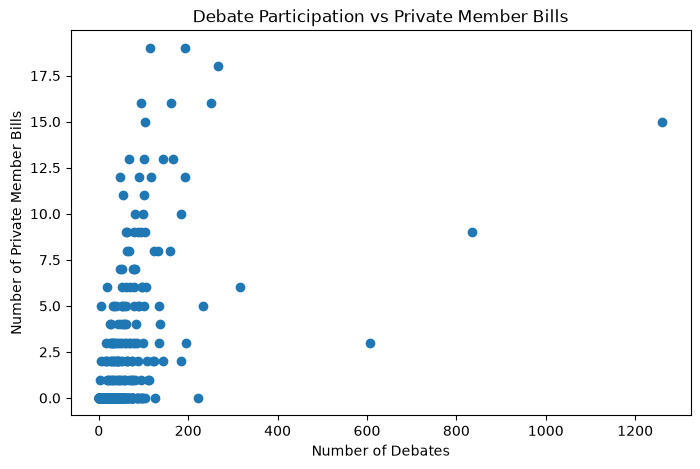

In [250]:
plt.figure(figsize=(8, 5))
plt.scatter(df["Debates"], df["Private Member Bills"])

plt.title("Debate Participation vs Private Member Bills")
plt.xlabel("Number of Debates")
plt.ylabel("Number of Private Member Bills")

plt.show()

### Observation

All three participation indicators show positive relationships with one another.

The strongest association is between Debate participation and Private Member Bills
(r = 0.504), followed by Questions and Private Member Bills (r = 0.431).
Questions and Debate participation show the weakest relationship (r = 0.350).

The scatter plots show considerable variation around these relationships, indicating
that higher participation in one indicator does not necessarily correspond to
similarly high participation in another.

Overall, the three indicators are positively associated, but none shows a very
strong relationship with another.

In [251]:
from sklearn.preprocessing import StandardScaler
features = df[['Attendance_numeric','Questions','Debates','Private Member Bills']]
x_km = features.dropna()
scaler = StandardScaler()
x_scaled = scaler.fit_transform(x_km)
print(x_scaled)

[[ 0.74404606  0.57426658  0.30820194  2.07521475]
 [-3.44204956 -0.74758208 -0.52215318 -0.43584891]
 [-1.34726238 -1.23564928 -0.48440976 -0.43584891]
 ...
 [ 0.79448793  0.67594725  0.24529625  2.38909771]
 [ 0.23788796 -0.50354848 -0.42150407 -0.43584891]
 [-2.18564108  1.15723573 -0.53473431 -0.43584891]]


### Q16. Are there distinct participation profiles among representatives?



In [252]:
from sklearn.cluster import KMeans
model = KMeans(
    n_clusters= 4,
    random_state = 42,
    n_init = 10)

In [253]:
model.fit(x_scaled)

C:\Users\Tony\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1428: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=3.
  warnings.warn(


,"n_clusters n_clusters: int, default=8The number of clusters to form as well as the number ofcentroids to generate.For an example of how to choose an optimal value for `n_clusters` refer to:ref:`sphx_glr_auto_examples_cluster_plot_kmeans_silhouette_analysis.py`.",4
,"n_init n_init: 'auto' or int, default='auto'Number of times the k-means algorithm is run with different centroidseeds. The final results is the best output of `n_init` consecutive runsin terms of inertia. Several runs are recommended for sparsehigh-dimensional problems (see :ref:`kmeans_sparse_high_dim`).When `n_init='auto'`, the number of runs depends on the value of init:10 if using `init='random'` or `init` is a callable;1 if using `init='k-means++'` or `init` is an array-like... versionadded:: 1.2 Added 'auto' option for `n_init`... versionchanged:: 1.4 Default value for `n_init` changed to `'auto'`.",10
,"random_state random_state: int, RandomState instance or None, default=NoneDetermines random number generation for centroid initialization. Usean int to make the randomness deterministic.See :term:`Glossary <random_state>`.",42
,"init init: {'k-means++', 'random'}, callable or array-like of shape (n_clusters, n_features), default='k-means++'Method for initialization:* 'k-means++' : selects initial cluster centroids using sampling based on an empirical probability distribution of the points' contribution to the overall inertia. This technique speeds up convergence. The algorithm implemented is ""greedy k-means++"". It differs from the vanilla k-means++ by making several trials at each sampling step and choosing the best centroid among them.* 'random': choose `n_clusters` observations (rows) at random from data for the initial centroids.* If an array is passed, it should be of shape (n_clusters, n_features) and gives the initial centers.* If a callable is passed, it should take arguments X, n_clusters and a random state and return an initialization.For an example of how to use the different `init` strategies, see:ref:`sphx_glr_auto_examples_cluster_plot_kmeans_digits.py`.For an evaluation of the impact of initialization, see the example:ref:`sphx_glr_auto_examples_cluster_plot_kmeans_stability_low_dim_dense.py`.",'k-means++'
,"max_iter max_iter: int, default=300Maximum number of iterations of the k-means algorithm for asingle run.",300
,"tol tol: float, default=1e-4Relative tolerance with regards to Frobenius norm of the differencein the cluster centers of two consecutive iterations to declareconvergence.",0.0001
,"verbose verbose: int, default=0Verbosity mode.",0
,"copy_x copy_x: bool, default=TrueWhen pre-computing distances it is more numerically accurate to centerthe data first. If copy_x is True (default), then the original data isnot modified. If False, the original data is modified, and put backbefore the function returns, but small numerical differences may beintroduced by subtracting and then adding the data mean. Note that ifthe original data is not C-contiguous, a copy will be made even ifcopy_x is False. If the original data is sparse, but not in CSR format,a copy will be made even if copy_x is False.",True
,"algorithm algorithm: {""lloyd"", ""elkan""}, default=""lloyd""K-means algorithm to use. The classical EM-style algorithm is `""lloyd""`.The `""elkan""` variation can be more efficient on some datasets withwell-defined clusters, by using the triangle inequality. However it'smore memory intensive due to the allocation of an extra array of shape`(n_samples, n_clusters)`... versionchanged:: 0.18 Added Elkan algorithm.. versionchanged:: 1.1 Renamed ""full"" to ""lloyd"", and deprecated ""auto"" and ""full"". Changed ""auto"" to use ""lloyd"" instead of ""elkan"".",'lloyd'
Name,Type,Value
"cluster_centers_ cluster_centers_: ndarray of shape (n_clusters, n_features)Coordinates of cluster centers. If the algorithm stops before fullyconverging (see ``tol`` and ``max_iter``), these will not beconsistent with ``labels_``.","ndarray[float64](4, 4)","[[ 0.

In [254]:
clusters = model.labels_
print(clusters)

[1 2 2 2 2 2 2 1 0 2 2 0 2 0 0 2 0 2 0 0 1 0 0 2 0 0 0 0 0 0 2 0 0 0 1 2 0
 0 0 0 0 0 0 0 0 0 0 2 2 2 2 0 0 0 0 0 0 0 0 0 2 0 0 0 0 1 2 0 1 0 1 0 2 0
 0 2 0 0 0 0 1 0 0 0 0 0 2 0 0 0 2 2 0 0 0 0 0 0 2 0 1 0 0 0 1 0 1 0 0 2 0
 0 0 2 0 0 0 0 0 1 0 0 0 2 1 2 0 0 0 0 0 0 0 0 2 2 0 0 0 2 0 0 0 0 0 1 0 0
 0 0 0 0 0 0 2 2 0 0 0 2 0 1 2 2 1 0 0 0 2 0 0 1 0 0 0 0 1 0 0 0 0 0 0 0 0
 0 0 2 0 0 0 0 2 2 0 0 0 0 0 0 0 0 0 2 0 0 2 0 0 0 0 2 1 2 2 0 2 2 0 1 0 3
 2 0 0 0 0 0 0 1 0 0 0 1 2 0 0 0 0 0 0 2 0 0 0 2 3 0 2 0 1 0 0 1 1 0 0 2 0
 2 0 0 2 2 1 2 0 0 0 0 0 2 2 0 0 2 0 0 2 1 2 0 0 0 1 1 0 0 1 2 0 0 2 0 0 0
 0 0 1 2 0 0 0 0 2 0 0 0 1 0 0 0 0 0 0 2 0 0 0 0 0 2 0 0 0 0 0 0 3 0 0 0 0
 2 0 1 0 0 2 0 0 1 0 0 1 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 1 2 0 0 0 0 0 0 0
 2 0 0 0 0 0 0 0 0 0 0 0 0 0 0 1 1 0 0 0 0 0 0 0 2 2 0 0 0 0 0 2 2 1 0 0 0
 0 0 2 0 1 2 0 0 2 2 0 0 0 0 0 0 2 0 0 0 0 1 0 0 0 0 0 1 2 0 1 2 0 1 0 0 2
 2 0 0 0 0 0 2 0 0 0 0 0 0 0 1 1 2 1 1 2 0 2 1 0 0 0 0 0 1 0 0 0 1 1 0 2 0
 2 0 0 0 0 0 0 0 0 0 0 2 

In [255]:
x_km['cluster'] = model.labels_
print(x_km)

     Attendance_numeric  Questions  Debates  Private Member Bills  cluster
0                 92.00        279       68                     8        1
1                 19.80         84        2                     0        2
2                 55.93         12        5                     0        2
3                 63.07          4        6                     0        2
4                 65.47        169       33                     0        2
..                  ...        ...      ...                   ...      ...
554               56.53        217       16                     0        2
555               96.73        183       48                     0        0
556               92.87        294       63                     9        1
557               83.27        120       10                     0        0
558               41.47        365        1                     0        2

[525 rows x 5 columns]


In [256]:
print(model.cluster_centers_)

[[ 0.34077159 -0.03873319 -0.10828544 -0.25869853]
 [ 0.59432522  1.24475374  0.81324476  2.32183708]
 [-1.57673932 -0.59435637 -0.37977455 -0.4234179 ]
 [ 0.52894336  1.48713301 10.77990251  2.38909771]]


In [257]:
centers = scaler.inverse_transform(model.cluster_centers_)

centers_df = pd.DataFrame(
    centers,
    columns=['Attendance_numeric', 'Questions', 'Debates', 'Private Member Bills']
)

print(centers_df)


   Attendance_numeric   Questions     Debates  Private Member Bills
0           85.044493  188.569863   34.895890              0.564384
1           89.417679  377.910714  108.142857              8.785714
2           51.972079  106.603960   13.316832              0.039604
3           88.290000  413.666667  900.333333              9.000000


In [258]:
x_km["cluster"].value_counts().sort_index()

cluster
0    365
1     56
2    101
3      3
Name: count, dtype: int64

In [259]:
cluster3 = x_km[x_km["cluster"] == 3]

print(cluster3)

     Attendance_numeric  Questions  Debates  Private Member Bills  cluster
235               73.40        610      834                     9        3
261               96.20        255      606                     3        3
351               95.27        376     1261                    15        3


In [260]:
x_km.groupby("cluster")[[
    "Attendance_numeric",
    "Questions",
    "Debates",
    "Private Member Bills"
]].mean()

,Attendance_numeric,Questions,Debates,Private Member Bills
cluster,,,,
0,85.044493,188.569863,34.895890,0.564384
1,89.417679,377.910714,108.142857,8.785714
2,51.972079,106.603960,13.316832,0.039604
3,88.290000,413.666667,900.333333,9.000000


In [261]:
from sklearn.decomposition import PCA
pca = PCA(n_components =2)
x_pca = pca.fit_transform(x_scaled)

In [262]:
print(x_pca.shape)

(525, 2)


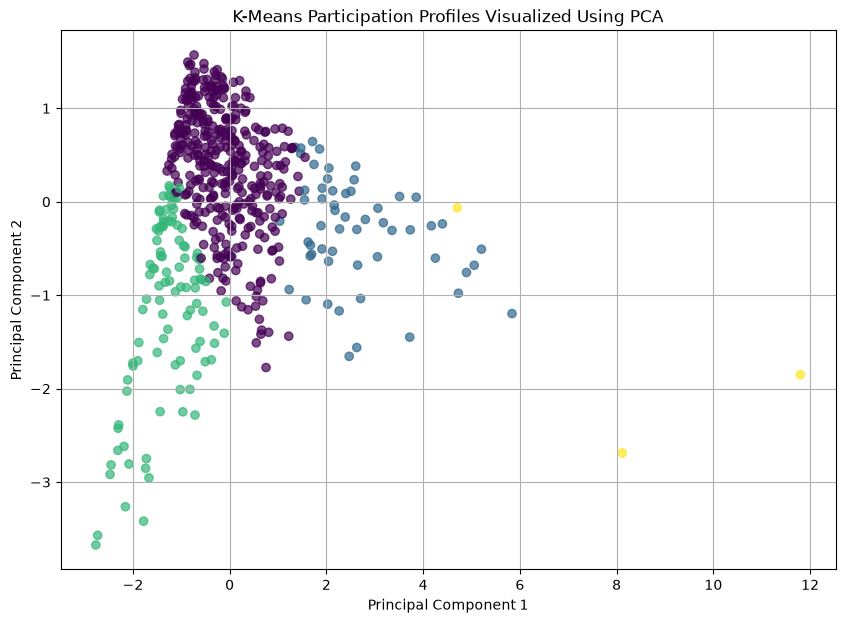

In [263]:
plt.figure(figsize=(10, 7))

plt.scatter(
    x_pca[:, 0],
    x_pca[:, 1],
    c=model.labels_,
    alpha=0.7
)

plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.title("K-Means Participation Profiles Visualized Using PCA")
plt.grid(True)
plt.show()

In [264]:
from sklearn.metrics import silhouette_score
silhouette_scores = {}

for k in range(2, 7):

    km = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    )

    labels = km.fit_predict(x_scaled)

    score = silhouette_score(x_scaled, labels)

    silhouette_scores[k] = score

silhouette_scores

C:\Users\Tony\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1428: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=3.
  warnings.warn(
C:\Users\Tony\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1428: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=3.
  warnings.warn(
C:\Users\Tony\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1428: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=3.
  warnings.warn(
C:\Users\Tony\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1428: UserWarning: KMeans is known to have a memory leak on Windows wi

{2: 0.5170160969891238,
 3: 0.3392663248855432,
 4: 0.3503582966936839,
 5: 0.3370013332406842,
 6: 0.3038844219182121}


#### Analysis
K-Means clustering was applied to Attendance, Questions, Debates, and Private Member Bills after standardizing the features. Representatives with incomplete values for these participation indicators were excluded from the clustering analysis, leaving 525 representatives.

A four-cluster solution was initially examined to identify more detailed participation profiles. Cluster centroids were then examined to understand the characteristics of each group.

PCA was subsequently used to project the standardized four-dimensional participation data into two principal components for visualization.

Finally, silhouette scores were calculated for K = 2 through K = 6 to evaluate the separation and cohesion of alternative cluster solutions.

#### Findings
The initial four-cluster solution identified four distinct exploratory profiles:

- A large group with relatively high attendance, moderate participation, and very low Private Member Bill activity.
- A smaller group with higher levels of questions, debates, and Private Member Bills.
- A group characterized by comparatively lower attendance and lower overall participation.
- A very small group of three representatives with exceptionally high debate participation.

However, silhouette analysis showed that the two-cluster solution produced the highest silhouette score (0.517), while the scores for K = 3 to K = 6 ranged from approximately 0.303 to 0.350.

This indicates that the data has a stronger broad two-group structure than a sharply separated four-group structure. The four-cluster solution therefore provides useful exploratory detail rather than definitive performance categories.

#### Visualization Choice
A PCA scatter plot was used to visualize the clustering structure in two dimensions. Silhouette scores across different values of K were plotted to assess the quality of alternative cluster solutions.

#### Observation
The participation indicators exhibit a broad underlying separation between representatives, with the strongest cluster separation occurring at K = 2. The four-cluster solution reveals additional exploratory patterns, including a very small group associated with exceptionally high debate participation, but these finer profiles show greater overlap. Therefore, the clustering results are best interpreted as exploratory participation profiles rather than objective rankings of parliamentary performance.

Silhouette analysis indicated that the participation data exhibited its strongest separation at K=2, while the K=4 solution provided additional exploratory detail but with greater cluster overlap

In [265]:
from pathlib import Path

Path("../.gitignore").write_text(
    """.ipynb_checkpoints/
__pycache__/
*.pyc
.env
""",
    encoding="utf-8"
)

44

In [269]:
from pathlib import Path

gitignore = Path("../.gitignore")
print(gitignore.exists())

True
